# Deskripsi Data

Projek ini melakukan Market Basket Analysis pada data transaksi sebuah bakery dengan :
- Menganalisi pola pembelian berdasarkan waktu (bulan, hari, jam)
- Mengetahui produk yang paling laris
- Membangun Association Rule menggunakan Algoritma Apriori untuk melihat produk apa yang sering dibeli secara bersamaan

Struktur Dataset bakery ini berisi 5 kolom, yaitu :
- Transaction : ID transaksi
- Item : nama produk yang dibeli
- date_time : waktu transaksi dalam format string, misal 30-10-2016 09:58
- period_day : periode waktu hari, misal morning
- weekday_weekend : kategori hari kerja atau hari pekan
Dataset ini terdiri dari 20507 baris dan 5 kolom

# Import Library dan Load Data

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

from mlxtend.frequent_patterns import association_rules, apriori

- Mengimpor pandas, numpy, matplotlib, seaborn untuk analisis dan visualisasi.
- Membaca dataset asli ke dalam dataframe sebagai sumber utama data. 

In [2]:
df = pd.read_csv("bread basket in london.csv")

# Data Preprocessing

In [3]:
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [5]:
print('Jumlah total transaksi', df['Transaction'].nunique())

Jumlah total transaksi 9465


In [6]:
# menghitung jumlah barang yang terjual
print('Jumlah total barang yang dijual', df['Item'].nunique())

Jumlah total barang yang dijual 94


In [7]:
# Konversikan kolom date_time ke format yang tepat agar lebih mudah diekstraksi.
df['date_time'] = pd.to_datetime(df['date_time'])
df.head()

C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\1992491444.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['date_time'])


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,2016-10-30 09:58:00,morning,weekend
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend
4,3,Jam,2016-10-30 10:07:00,morning,weekend


In [8]:
# extracting date
df['date'] = df['date_time'].dt.date

# extracting hour
df['hour'] = df['date_time'].dt.hour

# extracting month and display full name of the month
df['month'] = df['date_time'].dt.strftime('%Y-%m')

# extracting weekday and display full name of the weekday
df['weekday'] = df['date_time'].dt.strftime('%A')

# dropping date_time column as it's not necessary anymore
df.drop('date_time', axis = 1, inplace = True)

df.head()

,Transaction,Item,period_day,weekday_weekend,date,hour,month,weekday
0,1,Bread,morning,weekend,2016-10-30,9,2016-10,Sunday
1,2,Scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
2,2,Scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
3,3,Hot chocolate,morning,weekend,2016-10-30,10,2016-10,Sunday
4,3,Jam,morning,weekend,2016-10-30,10,2016-10,Sunday


In [9]:
# change the item name to lowercase and remove any spaces
df['Item'] = df['Item'].str.strip()
df['Item'] = df['Item'].str.lower()
df.head()

,Transaction,Item,period_day,weekday_weekend,date,hour,month,weekday
0,1,bread,morning,weekend,2016-10-30,9,2016-10,Sunday
1,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
2,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
3,3,hot chocolate,morning,weekend,2016-10-30,10,2016-10,Sunday
4,3,jam,morning,weekend,2016-10-30,10,2016-10,Sunday


In [10]:
df.shape

(20507, 8)

# MODIFIKASI

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   period_day       20507 non-null  object
 3   weekday_weekend  20507 non-null  object
 4   date             20507 non-null  object
 5   hour             20507 non-null  int32 
 6   month            20507 non-null  object
 7   weekday          20507 non-null  object
dtypes: int32(1), int64(1), object(6)
memory usage: 1.2+ MB


In [12]:


# Atur agar pandas menampilkan semua baris (None artinya tidak terbatas)
pd.set_option('display.max_rows', None)

# Sekarang saat Anda print, semua item akan muncul
print(df['Item'].value_counts())

# (Opsional) Kembalikan ke pengaturan default jika sudah selesai
pd.reset_option('display.max_rows')

Item
coffee                           5471
bread                            3325
tea                              1435
cake                             1025
pastry                            856
sandwich                          771
medialuna                         616
hot chocolate                     590
cookies                           540
brownie                           379
farm house                        374
muffin                            370
alfajores                         369
juice                             369
soup                              342
scone                             327
toast                             318
scandinavian                      277
truffles                          193
coke                              185
spanish brunch                    172
fudge                             159
baguette                          152
jam                               149
tiffin                            146
mineral water                     136
jammie 

In [42]:
import pandas as pd

# 1. Buat salinan ke df_clean agar data asli aman
df_clean = df.copy()

# 2. Pastikan nama item konsisten (menggunakan df_clean)
df_clean['Item'] = df_clean['Item'].str.lower().str.strip()

# --- DEFINISI KATEGORI ---

def get_category(item):
    # 1. Kategori EVENT
    event_list = [
        'afternoon with the baker', 'argentina night'
    ]
    
    # 2. Kategori MERCHANDISE
    # Termasuk voucher hadiah, kartu pos, kaos, tas
    merch_list = [
        'tshirt', 'nomad bag', 'postcard', "valentine's card", 'gift voucher', 
        'basket', 'art tray', 'christmas common', 'fairy doors', 'hack the stack',
        'siblings', 'the bart' # Asumsi barang fisik/printilan
    ]
    
    # 3. Kategori PANTRY & EXTRAS
    # Termasuk bahan mentah, selai toples, keripik kemasan, dan 'Adjustment'
    pantry_extras_list = [
        'jam', 'honey', 'coffee granules', 'drinking chocolate spoons', 
        "ella's kitchen pouches", 'chimichurri oil', 'extra salami or feta', 
        'crisps', 'bare popcorn', 'muesli', 'granola', 'gingerbread syrup', 
        'duck egg', 'bacon', 'polenta', 'olum & polenta', 'spread', 
        'dulce de leche', 'pick and mix bowls', 'adjustment' # Dimasukkan ke sini sebagai 'Extras'
    ]

    # LOGIKA PENGELOMPOKKAN
    if item in event_list:
        return 'Event'
    elif item in merch_list:
        return 'Merchandise'
    elif item in pantry_extras_list:
        return 'Pantry & Extras'
    else:
        # SEMUA sisanya (Coffee, Bread, Cake, Sandwich, dll) masuk sini
        return 'Makanan dan Minuman'

# --- TERAPKAN KE DATA (df_clean) ---

# Buat kolom baru di df_clean
df_clean['Category'] = df_clean['Item'].apply(get_category)

# --- LIHAT HASILNYA ---

print("--- Jumlah Transaksi per Kategori ---")
print(df_clean['Category'].value_counts())

print("\n--- Contoh Data (5 baris pertama ---")
print(df_clean[['Item', 'Category']].head())

print("\n--- Cek Detail: Apa saja isi Pantry & Extras? ---")
print(df_clean[df_clean['Category'] == 'Pantry & Extras']['Item'].unique())

--- Jumlah Transaksi per Kategori ---
Category
Makanan dan Minuman    20007
Pantry & Extras          334
Merchandise              115
Event                     51
Name: count, dtype: int64

--- Contoh Data (5 baris pertama ---
            Item             Category
0          bread  Makanan dan Minuman
1   scandinavian  Makanan dan Minuman
2   scandinavian  Makanan dan Minuman
3  hot chocolate  Makanan dan Minuman
4            jam      Pantry & Extras

--- Cek Detail: Apa saja isi Pantry & Extras? ---
['jam' "ella's kitchen pouches" 'pick and mix bowls' 'dulce de leche'
 'honey' 'granola' 'adjustment' 'chimichurri oil' 'bacon' 'spread'
 'olum & polenta' 'polenta' 'bare popcorn' 'muesli' 'crisps'
 'gingerbread syrup' 'extra salami or feta' 'duck egg' 'coffee granules'
 'drinking chocolate spoons']


In [39]:
# ... (Pastikan kode pengelompokan di atas sudah dijalankan sebelumnya) ...

# Mengambil daftar item unik per kategori
kategori_items = df_clean.groupby('Category')['Item'].unique()

# Menampilkan hasil
for kategori, items in kategori_items.items():
    print(f"\n=== KATEGORI: {kategori.upper()} ({len(items)} item) ===")
    # Menggabungkan item dengan koma agar rapi
    print(", ".join(sorted(items)))
    print("-" * 50)


=== KATEGORI: EVENT (2 item) ===
afternoon with the baker, argentina night
--------------------------------------------------

=== KATEGORI: MAKANAN DAN MINUMAN (60 item) ===
alfajores, baguette, bakewell, bowl nic pitt, bread, bread pudding, brioche and salami, brownie, cake, caramel bites, cherry me dried fruit, chicken sand, chicken stew, chocolates, coffee, coke, cookies, crepes, eggs, empanadas, farm house, focaccia, frittata, fudge, half slice monster, hearty & seasonal, hot chocolate, jammie dodgers, juice, keeping it local, kids biscuit, lemon and coconut, medialuna, mighty protein, mineral water, mortimer, muffin, my-5 fruit shoot, panatone, pastry, pintxos, raspberry shortbread sandwich, raw bars, salad, sandwich, scandinavian, scone, smoothies, soup, spanish brunch, tacos/fajita, tartine, tea, the nomad, tiffin, toast, truffles, vegan feast, vegan mincepie, victorian sponge
--------------------------------------------------

=== KATEGORI: MERCHANDISE (12 item) ===
art tray,

# Exploratory Data Analysis (EDA) dan Visualisasi

Bagian ini menganalisis karakteristik dataset sebelum dilakukan pemodelan.
- Melihat dimensi data, contoh data, dan kolom.
- Mengubah kolom date_time menjadi datetime.
- Membuat fitur tambahan seperti month, day, hour.
- Visualisasi item terlaris dan distribusi transaksi berdasarkan waktu.
Tujuan: memahami pola pembelian, kapan transaksi ramai, dan produk paling populer.

In [46]:
df.shape

(20507, 8)

In [47]:
df.head()

,Transaction,Item,period_day,weekday_weekend,date,hour,month,weekday
0,1,bread,morning,weekend,2016-10-30,9,2016-10,Sunday
1,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
2,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
3,3,hot chocolate,morning,weekend,2016-10-30,10,2016-10,Sunday
4,3,jam,morning,weekend,2016-10-30,10,2016-10,Sunday


### Best selling items

In [48]:
# Pastikan variabel 'df_clean' sudah dibuat/dijalankan di cell sebelumnya

# 1. Hitung jumlah item terjual menggunakan 'df_clean'
# Kita ganti sumber datanya menjadi df_clean['Item']
top_items = pd.DataFrame(df_clean['Item'].value_counts(dropna=True, sort=True)).reset_index()

# 2. Ubah nama kolom menjadi 'item' dan 'count'
top_items.columns = ['item', 'count']

# 3. Hitung persentase penjualan
top_items['percentage'] = top_items['count'].apply(lambda x: x / top_items['count'].sum())

# 4. Ambil 10 produk teratas
top_10_items = top_items.head(10)

# 5. Tampilkan hasil
top_10_items

,item,count,percentage
0,coffee,5471,0.266787
1,bread,3325,0.162140
2,tea,1435,0.069976
3,cake,1025,0.049983
4,pastry,856,0.041742
5,sandwich,771,0.037597
6,medialuna,616,0.030039
7,hot chocolate,590,0.028771
8,cookies,540,0.026332
9,brownie,379,0.018481


C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\2703705142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='item', y='count', data=top_10_items, palette='viridis')


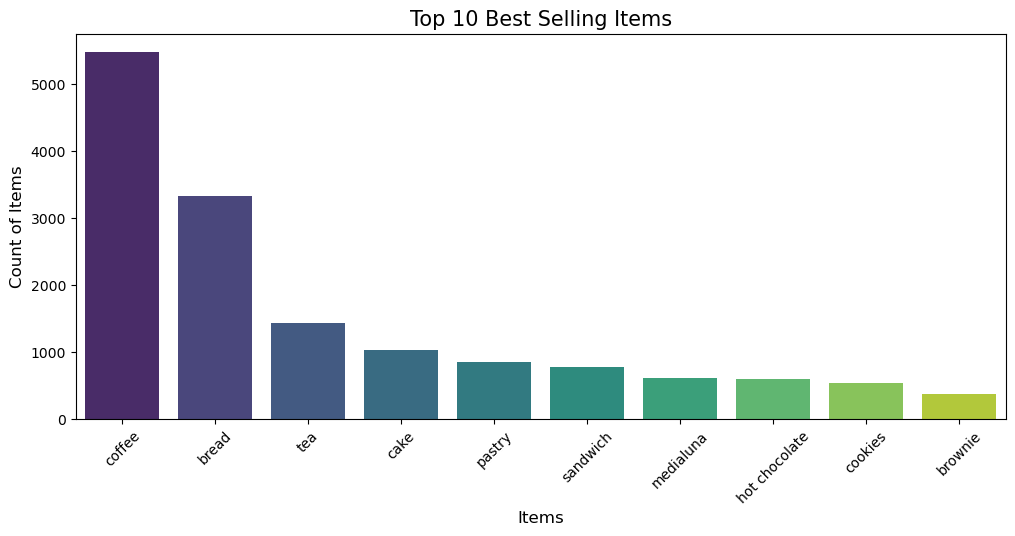

In [49]:
# Pastikan Anda menggunakan 'top_10_items' yang sudah di-filter 10 teratas
plt.figure(figsize=(12,5))
sns.barplot(x='item', y='count', data=top_10_items, palette='viridis')

plt.xlabel('Items', size=12)
plt.xticks(rotation=45)
plt.ylabel('Count of Items', size=12)
plt.title('Top 10 Best Selling Items', size=15)
plt.show()

### Number of items per transaction

In [50]:
# 1. Hitung jumlah item di setiap transaksi menggunakan data bersih ('df_clean')
items_num = df_clean.groupby('Transaction', as_index=False)['Item'].count()

# 2. Pivot table untuk menampilkan distribusi transaksi berdasarkan jumlah item
# Catatan: Di langkah ini, kolom 'Item' berisi angka jumlah barang (1, 2, 3...)
items_num = items_num.pivot_table(index='Item', values='Transaction', aggfunc='count')

# 3. Ubah nama kolom agar tidak membingungkan saat ditampilkan
# Index 'Item' sebenarnya adalah "Jumlah Barang", dan Value 'Transaction' adalah "Jumlah Transaksi"
items_num.index.name = 'Number of Items in Basket'
items_num.columns = ['Number of Transactions']

# 4. Hitung persentase
items_num['percentage'] = items_num['Number of Transactions'].apply(lambda x: x / items_num['Number of Transactions'].sum())

# 5. Tampilkan hasil
items_num

,Number of Transactions,percentage
Number of Items in Basket,,
1,3631,0.383624
2,2908,0.307237
3,1528,0.161437
4,850,0.089805
5,341,0.036027
6,135,0.014263
7,38,0.004015
8,21,0.002219
9,7,0.000740


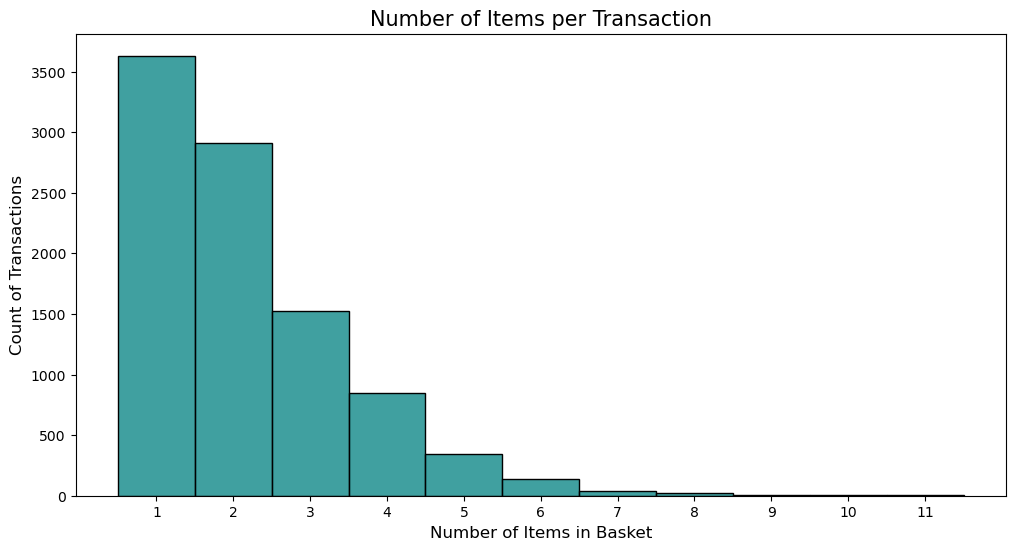

In [51]:


# Mengatur ukuran gambar agar lebih jelas
plt.figure(figsize=(12, 6))

# Cek nama kolom yang tersedia (agar kode tidak error beda versi)
col_weight = 'Number of Transactions'
if 'Number of Transactions' not in items_num.columns:
    col_weight = 'Transaction' # Fallback jika kolom belum direname

# Membuat plot
# x = index (jumlah barang: 1, 2, 3...)
# weights = frekuensi (berapa banyak transaksi yang isinya segitu)
ax = sns.histplot(x=items_num.index, weights=items_num[col_weight], discrete=True, color='teal')

# Memberi label dan judul
plt.xlabel('Number of Items in Basket', size=12)
plt.ylabel('Count of Transactions', size=12)
plt.title('Number of Items per Transaction', size=15)

# Mengatur sumbu X agar menampilkan semua angka (1, 2, 3...) tanpa koma
# Kita hanya ambil index yang ada datanya
ax.set_xticks(items_num.index)

plt.show()

### Quantity Sold by Month

In [52]:
# Hitung kuantitas item yang terjual per bulan menggunakan data bersih
# Ganti 'df' menjadi 'df_clean'
qty_month = df_clean.groupby('month', as_index=False)['Transaction'].count()
qty_month.columns = ['month', 'quantity_sold']

qty_month.head()

,month,quantity_sold
0,2016-10,369
1,2016-11,4436
2,2016-12,3339
3,2017-01,3356
4,2017-02,3906


C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\324700551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='quantity_sold', data=qty_month, palette='viridis')


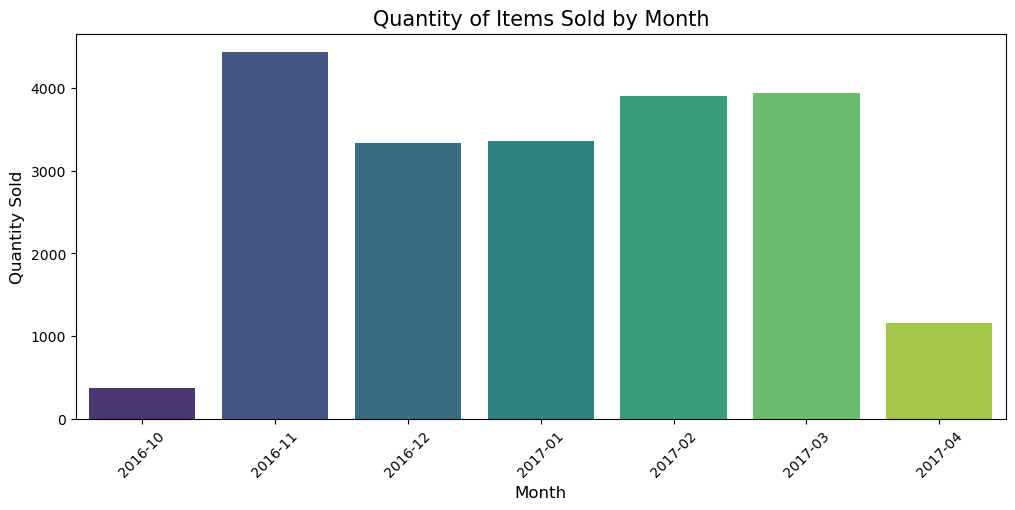

In [53]:


plt.figure(figsize=(12, 5))

# Membuat bar plot
sns.barplot(x='month', y='quantity_sold', data=qty_month, palette='viridis')

plt.xlabel('Month', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity of Items Sold by Month', size=15)
plt.xticks(rotation=45) # Memutar label bulan agar tidak bertumpuk
plt.show()

### Quantity Sold by Days of Week

In [54]:
# 1. Hitung transaksi per hari menggunakan data bersih
qty_wd = df_clean.groupby('weekday', as_index=False)['Transaction'].count()

# 2. Ganti nama kolom agar lebih jelas
qty_wd.columns = ['weekday', 'quantity_sold']

# 3. Mengurutkan hari dengan cara yang lebih aman (Categorical Sort)
# Kita tentukan urutan yang kita inginkan: Senin -> Minggu
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Mengubah kolom weekday menjadi tipe data kategori dengan urutan yang ditentukan
qty_wd['weekday'] = pd.Categorical(qty_wd['weekday'], categories=days_order, ordered=True)

# 4. Sortir berdasarkan urutan kategori tadi
qty_wd.sort_values('weekday', inplace=True)

# 5. Tampilkan hasil
qty_wd

,weekday,quantity_sold
1,Monday,2324
5,Tuesday,2392
6,Wednesday,2321
4,Thursday,2646
0,Friday,3124
2,Saturday,4605
3,Sunday,3095


C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\1816354948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weekday', y='quantity_sold', data=qty_wd, palette='viridis')


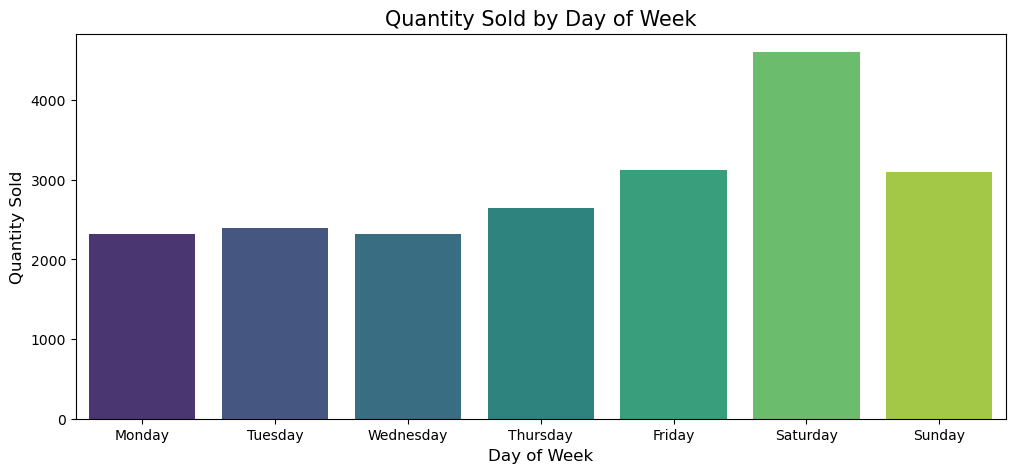

In [55]:

plt.figure(figsize=(12,5))

sns.barplot(x='weekday', y='quantity_sold', data=qty_wd, palette='viridis')

plt.xlabel('Day of Week', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity Sold by Day of Week', size=15)
plt.show()

### Quantity Sold by Hours

In [56]:
# 1. Hitung jumlah item terjual berdasarkan jam (hour) dari data bersih
# Ganti 'df' menjadi 'df_clean'
qty_hr = df_clean.groupby('hour', as_index=False)['Transaction'].count()

# 2. Rename kolom agar konsisten dan jelas
qty_hr.columns = ['hour', 'quantity_sold']

# 3. Membuat bins (opsional, tapi jika Anda ingin label interval)
# Ganti range menjadi (0, 25) agar jam 23.00 - 23.59 tetap terhitung
qty_hr['hour_bins'] = pd.cut(qty_hr['hour'], bins=range(0, 25, 1), right=False)

# 4. Tampilkan hasil
qty_hr.head()

,hour,quantity_sold,hour_bins
0,1,1,"[1, 2)"
1,7,24,"[7, 8)"
2,8,645,"[8, 9)"
3,9,1966,"[9, 10)"
4,10,2666,"[10, 11)"


C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\2217724875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='quantity_sold', data=qty_hr, palette='viridis')


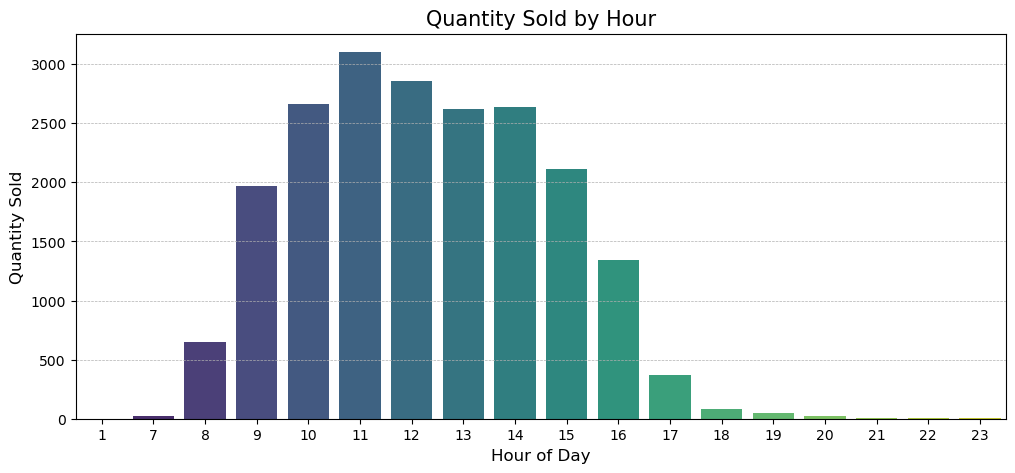

In [57]:


plt.figure(figsize=(12, 5))

# Kita gunakan 'hour' (angka) sebagai sumbu X agar lebih mudah dibaca daripada interval bins
sns.barplot(x='hour', y='quantity_sold', data=qty_hr, palette='viridis')

plt.xlabel('Hour of Day', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity Sold by Hour', size=15)

# Menambahkan grid tipis agar mudah melihat level ketinggian batang
plt.grid(axis='y', ls='--', lw=0.5)

plt.show()

## Algoritma Apriori dengan Market Basket Analysis

In [58]:
# select only required variables for modelling
transactions = df_clean.groupby(['Transaction', 'Item'])['Item'].count().reset_index(name ='Count')
transactions.head()

,Transaction,Item,Count
0,1,bread,1
1,2,scandinavian,2
2,3,cookies,1
3,3,hot chocolate,1
4,3,jam,1


Fungsi apriori mengharapkan data masukan dalam DataFrame pandas yang dienkode one-hot, oleh karena itu, kita perlu mengubah DataFrame di atas menjadi representasi variabel kategorikal sebagai vektor biner.

In [59]:
# Membuat pivot table
# aggfunc='sum' akan menjumlahkan item (misal beli 2 roti jadi angka 2)
my_basket = transactions.pivot_table(index='Transaction', columns='Item', values='Count', aggfunc='sum').fillna(0)

# Langkah PENTING: Encoding (Mengubah semua angka > 0 menjadi 1)
# Apriori hanya butuh info "dibeli" (1) atau "tidak" (0), tidak peduli jumlahnya.
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Terapkan fungsi encoding
my_basket = my_basket.applymap(encode_units)

# Tampilkan hasilnya
my_basket.head()

C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\671920862.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  my_basket = my_basket.applymap(encode_units)


Item,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Minimun sippport adalah ambang batas frekuensi atau kemunculan minimum yang harus dipenuhi oleh suatu itemset agar dianggap sering muncul.

suatu itemset dianggap sering muncul jika muncul setidaknya 1% dari total jumlah transaksi (1% dari 9465).

In [60]:
# create frequent items df with itemsets and support columns by using `apriori` function
frequent_items = apriori(my_basket, min_support = 0.01, use_colnames = True)
frequent_items

C:\Users\Andini\anaconda3\envs\proyek_cv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.036344,(alfajores)
1,0.016059,(baguette)
2,0.327205,(bread)
3,0.040042,(brownie)
4,0.103856,(cake)
...,...,...
56,0.023666,"(toast, coffee)"
57,0.014369,"(sandwich, tea)"
58,0.010037,"(bread, cake, coffee)"
59,0.011199,"(bread, pastry, coffee)"


Lift menunjukkan berapa kali A dan B benar-benar muncul dalam urutan yang sama, dibandingkan jika tidak ada hubungan di antara keduanya. Dengan kata lain, ia memperhitungkan dukungan dari setiap item untuk mengukur kekuatan asosiasi di antara keduanya. Nilai lift 1 berarti tidak ada asosiasi antara kedua item tersebut. Nilai lift lebih besar dari 1 berarti kedua item tersebut berasosiasi positif, artinya kehadiran satu item meningkatkan kemungkinan kehadiran item lainnya.

Proyek ini akan menetapkan ambang batas minimum untuk metrik lift menjadi 1,2 untuk mengembalikan aturan asosiasi yang terjadi setidaknya 20% lebih sering daripada yang kita harapkan jika terjadi secara acak.

In [61]:
# create the rules from frequent itemset generated above with min lift = 1.2
# nilai lift untuk matriks
metric = "lift"
min_threshold = 1.2

rules = association_rules(frequent_items, metric = metric, min_threshold = min_threshold)[["antecedents", "consequents", "support", "confidence", "lift"]]
rules.sort_values('confidence', ascending = False, inplace = True)
rules.reset_index(drop=True, inplace = True)
rules

#jika membeli toast maka membeli coffee nilai supportnya sekian
#melihat nilai dari associationnya

,antecedents,consequents,support,confidence,lift
0,(toast),(coffee),0.023666,0.704403,1.472431
1,(spanish brunch),(coffee),0.010882,0.598837,1.251766
2,(cake),(tea),0.023772,0.228891,1.604781
3,"(tea, coffee)",(cake),0.010037,0.201271,1.937977
4,(sandwich),(tea),0.014369,0.200000,1.402222
5,(hot chocolate),(cake),0.011410,0.195652,1.883874
6,"(cake, coffee)",(tea),0.010037,0.183398,1.285822
7,(tea),(cake),0.023772,0.166667,1.604781
8,(pastry),"(bread, coffee)",0.011199,0.130061,1.444872
9,"(bread, coffee)",(pastry),0.011199,0.124413,1.444872


## Parallel coordinates plot

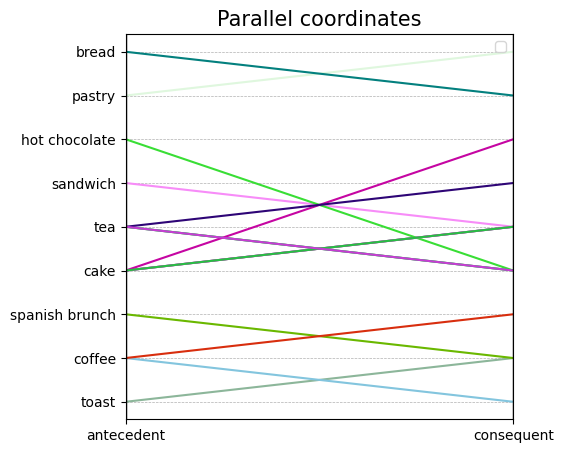

In [62]:
# Function to convert rules to coordinates.
def rules_to_coordinates(rules):
    rules['antecedent'] = rules['antecedents'].apply(lambda antecedent: list(antecedent)[0])
    rules['consequent'] = rules['consequents'].apply(lambda consequent: list(consequent)[0])
    rules['rule'] = rules.index
    return rules[['antecedent','consequent','rule']]

# import sub lib to plot parallel coordinates
from pandas.plotting import parallel_coordinates

# Convert rules into coordinates suitable for use in a parallel coordinates plot
coords = rules_to_coordinates(rules)

# Generate parallel coordinates plot
plt.figure(figsize=(5,5))
parallel_coordinates(coords, 'rule')
plt.legend([])
plt.grid(ls='--', lw='0.5')
plt.title('Parallel coordinates', size = 15)
plt.show()

## Itemsets Lift Heatmap

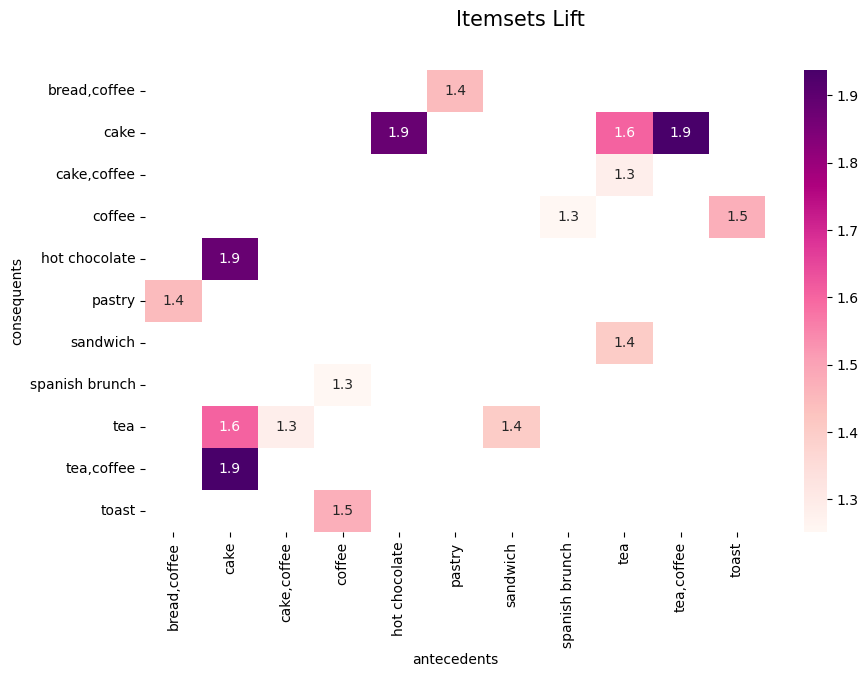

In [63]:
# convert antecedents and consequents into strings
rules['antecedents'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
rules['consequents'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

# transform antecedent, consequent, and support columns into matrix
support_table_lift = rules.pivot(index='consequents', columns='antecedents', values='lift')

# generate a heatmap with annotations 
plt.figure(figsize=(10,6))
sns.heatmap(support_table_lift, annot = True, cbar = True, cmap="RdPu")
plt.suptitle('Itemsets Lift', size = 15)

plt.show()

## Itemsets Confidence Heatmap

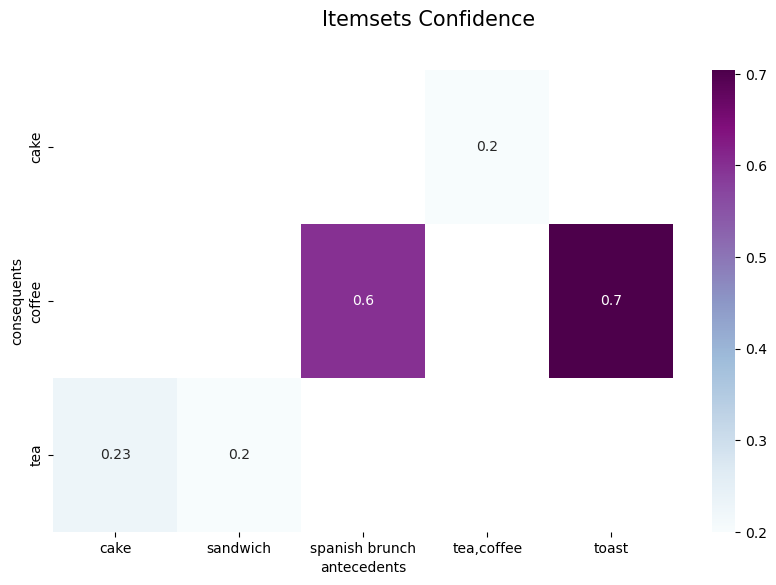

In [64]:
# transform antecedent, consequent, and support columns into matrix
rules_confidence = rules[rules['confidence']>=0.2] # select min lift=1.2
support_table_conf = rules_confidence.pivot(index='consequents', columns='antecedents', values='confidence')

# generate a heatmap with annotations
plt.figure(figsize=(10,6))
sns.heatmap(support_table_conf, annot = True, cbar = True, cmap="BuPu")
plt.suptitle('Itemsets Confidence', size = 15)

plt.show()

## Implementasi Apriori

# CROSS SELLING 

In [72]:
import pandas as pd

# --- PASTIKAN KODE KATEGORI (STEP 1) SUDAH DIJALANKAN DULU ---
# Kita gunakan df_clean yang sudah ada kategori-nya

# =================================================================
#  TAHAP 2: ANALISIS LIFT (FORMAT SESUAI FOTO)
# =================================================================

print("Sedang menghitung interaksi produk...")

# A. Tentukan HERO (Pemicu Trafik)
# Menggunakan df_clean agar konsisten
hero_data = df_clean[df_clean['Category'] == 'Makanan dan Minuman']
hero_counts = hero_data['Item'].value_counts().head(20)
hero_products_list = hero_counts.index.tolist()

# B. Tentukan TARGET
target_categories = ['Merchandise', 'Pantry & Extras', 'Event']
target_list = df_clean[df_clean['Category'].isin(target_categories)][['Item', 'Category']].drop_duplicates()

print(f"Jumlah Hero Product (Makanan/Minuman Populer): {len(hero_products_list)}")
print(f"Jumlah Target Product (Merch/Event/Pantry): {len(target_list)}")
print("-" * 50)

# C. PROSES HITUNG
bundles_final = []
total_seluruh_transaksi = df_clean['Transaction'].nunique()

# Pre-calculate support hero
hero_support_dict = {}
for h in hero_products_list:
    n_trans = df_clean[df_clean['Item'] == h]['Transaction'].nunique()
    hero_support_dict[h] = n_trans / total_seluruh_transaksi

# Loop Target
for i, row_target in target_list.iterrows():
    produk_target = row_target['Item']
    kategori_target = row_target['Category']
    
    # 1. Cari Transaksi Target
    transaksi_dengan_target = df_clean[df_clean['Item'] == produk_target]['Transaction'].unique()
    total_transaksi_target = len(transaksi_dengan_target)
    
    if total_transaksi_target == 0: continue

    # 2. Cari Hero di transaksi tersebut
    irisan_data = df_clean[
        (df_clean['Transaction'].isin(transaksi_dengan_target)) & 
        (df_clean['Item'].isin(hero_products_list))
    ]
    
    if not irisan_data.empty:
        # Hitung kemunculan bareng
        hero_counts_intersect = irisan_data.groupby('Item')['Transaction'].nunique()
        
        candidates = []
        for hero_name, count_together in hero_counts_intersect.items():
            confidence = count_together / total_transaksi_target
            support_hero = hero_support_dict[hero_name]
            lift = confidence / support_hero
            
            candidates.append({
                'Hero': hero_name,
                'Confidence': confidence,
                'Lift': lift,
                'Count': count_together
            })
        
        # Urutkan berdasarkan Lift tertinggi
        candidates.sort(key=lambda x: x['Lift'], reverse=True)
        best_match = candidates[0]
        
        # --- KEMBALIKAN LOGIKA MARKETING SESUAI FOTO ---
        hero_name = best_match['Hero']
        
        if kategori_target == 'Event':
            pesan = f"Tiket {produk_target} + Gratis {hero_name}"
        elif kategori_target == 'Merchandise':
            pesan = f"Loyalty: Beli 5x {hero_name}, Diskon 50% {produk_target}"
        else: # Pantry & Extras
            pesan = f"Paket Rumah: {hero_name} + Bahan {produk_target}"

        bundles_final.append({
            'Kategori_Target': kategori_target,
            'Target_Product': produk_target,
            'Pasangan_Hero': hero_name,
            'Lift_Score': round(best_match['Lift'], 2),
            # Format Detail Alasan sesuai foto: "Lift 25.93x. Dibeli bareng: 1x"
            'Detail_Alasan': f"Lift {round(best_match['Lift'], 2)}x. Dibeli bareng: {best_match['Count']}x",
            'Rekomendasi_Marketing': pesan
        })
        
    else:
        # Fallback (Manual)
        best_hero = hero_products_list[0]
        
        if kategori_target == 'Event':
            pesan = f"Bundle Event: Tiket {produk_target} Free {best_hero}"
        else:
            pesan = f"Coba Pajang {produk_target} di sebelah {best_hero}"

        bundles_final.append({
            'Kategori_Target': kategori_target,
            'Target_Product': produk_target,
            'Pasangan_Hero': best_hero,
            'Lift_Score': 0.00,
            'Detail_Alasan': "Tidak ada riwayat bersama",
            'Rekomendasi_Marketing': pesan
        })

# --- TAMPILKAN HASIL ---
df_rekomendasi_final = pd.DataFrame(bundles_final)
df_rekomendasi_final.sort_values(by=['Lift_Score'], ascending=False, inplace=True)

print("\n=== REKOMENDASI STRATEGI CROSS-SELLING PER KATEGORI ===")
cols_to_show = ['Kategori_Target', 'Target_Product', 'Pasangan_Hero', 'Lift_Score', 'Detail_Alasan', 'Rekomendasi_Marketing']

# Print tanpa index agar rapi seperti foto
print(df_rekomendasi_final[cols_to_show].to_string(index=False))

Sedang menghitung interaksi produk...
Jumlah Hero Product (Makanan/Minuman Populer): 20
Jumlah Target Product (Merch/Event/Pantry): 34
--------------------------------------------------

=== REKOMENDASI STRATEGI CROSS-SELLING PER KATEGORI ===
Kategori_Target            Target_Product Pasangan_Hero  Lift_Score                  Detail_Alasan                                  Rekomendasi_Marketing
Pantry & Extras                     bacon         juice       25.93 Lift 25.93x. Dibeli bareng: 1x                       Paket Rumah: juice + Bahan bacon
    Merchandise               fairy doors  scandinavian       17.21 Lift 17.21x. Dibeli bareng: 1x  Loyalty: Beli 5x scandinavian, Diskon 50% fairy doors
Pantry & Extras           chimichurri oil  scandinavian       17.21 Lift 17.21x. Dibeli bareng: 1x      Paket Rumah: scandinavian + Bahan chimichurri oil
Pantry & Extras                    crisps         juice       11.11 Lift 11.11x. Dibeli bareng: 6x                      Paket Rumah: juice + 

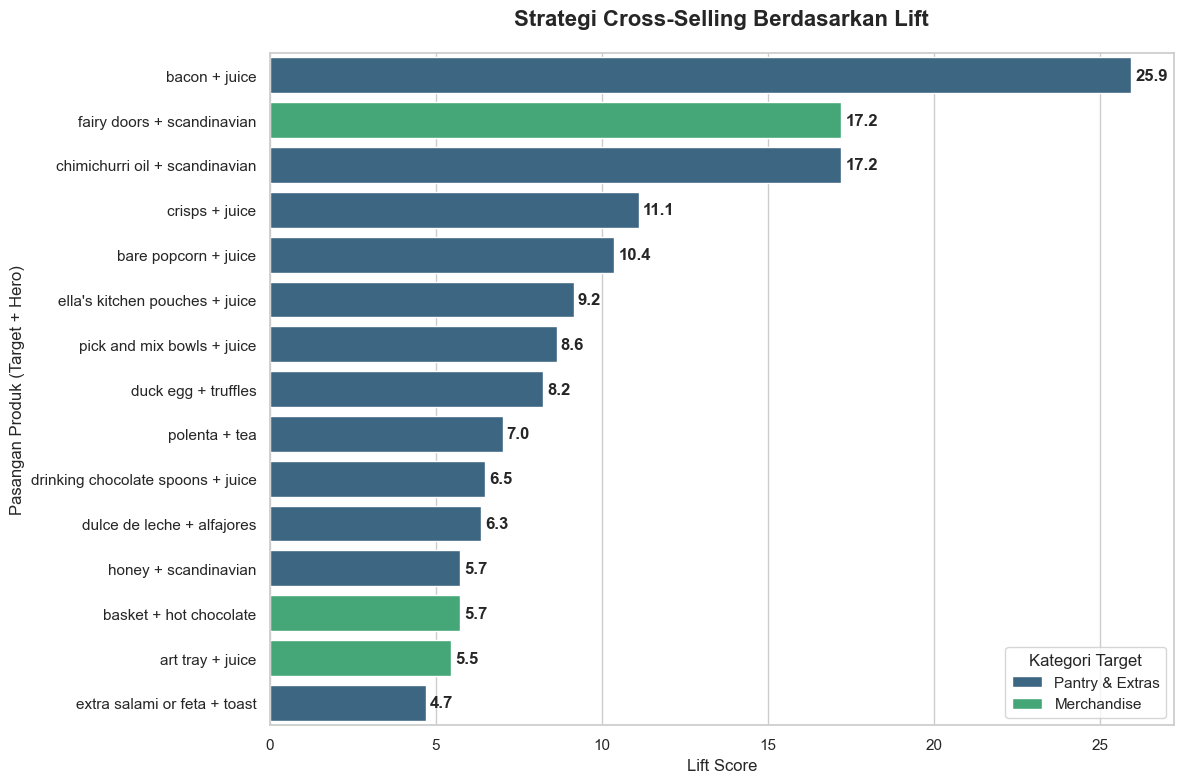

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PERSIAPAN DATA VISUALISASI ---
# Kita ambil Top 15 data dengan Lift > 0 agar grafik fokus pada peluang nyata
df_viz = df_rekomendasi_final[df_rekomendasi_final['Lift_Score'] > 0].head(15).copy()

# Membuat nama label gabungan agar mudah dibaca di grafik
# Contoh: "bacon + juice"
df_viz['Bundle_Label'] = df_viz['Target_Product'] + " + " + df_viz['Pasangan_Hero']

# Set Style
sns.set_theme(style="whitegrid")

# --- 2. MEMBUAT GRAFIK ---
fig, ax = plt.subplots(figsize=(12, 8))

# Membuat Bar Chart Horizontal
barplot = sns.barplot(
    data=df_viz,
    x='Lift_Score',
    y='Bundle_Label',
    hue='Kategori_Target', # Warna berbeda tiap kategori
    palette='viridis',
    dodge=False # Agar bar tidak mengecil
)

# --- 3. MEMPERCANTIK TAMPILAN ---
plt.title('Strategi Cross-Selling Berdasarkan Lift', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lift Score', fontsize=12)
plt.ylabel('Pasangan Produk (Target + Hero)', fontsize=12)

# Menambahkan angka Lift di ujung setiap batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold')

# Pindahkan Legenda ke tempat yang rapi
plt.legend(title='Kategori Target', loc='lower right')

plt.tight_layout()
plt.show()

C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\2447817858.py:59: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Andini\anaconda3\envs\proyek_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


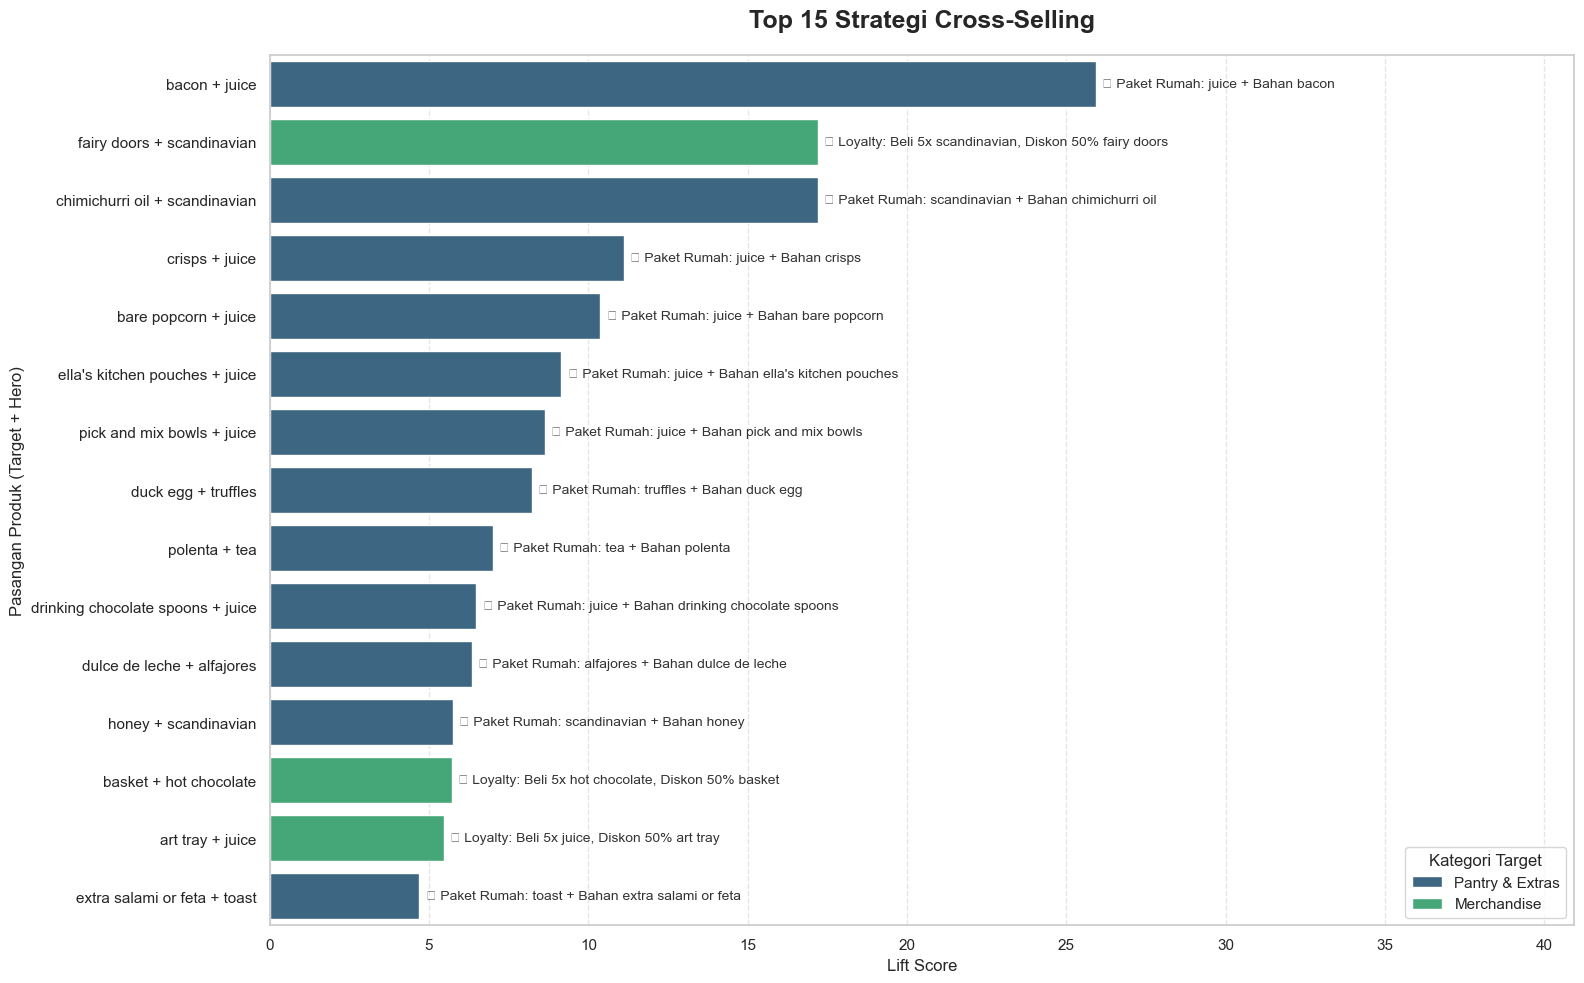

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. DATA PREPARATION ---
# Ambil Top 15 data dengan Lift > 0
df_viz = df_rekomendasi_final[df_rekomendasi_final['Lift_Score'] > 0].head(15).copy()

# Label untuk Y-Axis (Gabungan Produk)
df_viz['Bundle_Label'] = df_viz['Target_Product'] + " + " + df_viz['Pasangan_Hero']

# --- 2. SETUP GRAFIK ---
# Ukuran dibuat lebar (16) agar teks rekomendasi muat
fig, ax = plt.subplots(figsize=(16, 10))

# Membuat Bar Chart
barplot = sns.barplot(
    data=df_viz,
    x='Lift_Score',
    y='Bundle_Label',
    hue='Kategori_Target',
    palette='viridis',
    dodge=False,
    ax=ax
)

# --- 3. MENAMBAHKAN TEKS REKOMENDASI ---
# Loop untuk menempelkan teks di samping setiap batang
for i, (idx, row) in enumerate(df_viz.iterrows()):
    # Ambil nilai Lift untuk posisi X
    lift_val = row['Lift_Score']
    # Ambil teks rekomendasi
    pesan = row['Rekomendasi_Marketing']
    
    # Menulis Teks di Samping Batang
    # x = lift_val + 0.5 (memberi sedikit jarak dari ujung batang)
    # y = i (posisi baris)
    ax.text(
        x = lift_val + 0.2, 
        y = i, 
        s = f"💡 {pesan}", # Tambah ikon lampu agar menarik
        va = 'center', 
        fontsize = 10,
        fontweight = 'medium',
        color = '#333333' # Warna abu gelap
    )

# --- 4. FINISHING TOUCHES ---
plt.title('Top 15 Strategi Cross-Selling', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Lift Score', fontsize=12)
plt.ylabel('Pasangan Produk (Target + Hero)', fontsize=12)

# Menyesuaikan batas kanan grafik agar teks tidak terpotong
# Kita tambah 15 poin dari nilai lift tertinggi untuk ruang teks
plt.xlim(0, df_viz['Lift_Score'].max() + 15)

plt.legend(title='Kategori Target', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# CUCI GUDANG

In [77]:
import pandas as pd
import numpy as np

# --- 1. ANALISIS PERFORMA PRODUK (Dengan Konteks Kategori) ---

# Hitung penjualan per item
product_counts = df['Item'].value_counts().reset_index()
product_counts.columns = ['Produk', 'Jumlah_Terjual']

# Gabungkan dengan informasi Kategori agar kita tahu jenis barangnya
# (Kita ambil mapping kategori dari dataframe utama)
category_map = df_clean[['Item', 'Category']].drop_duplicates().set_index('Item')
product_counts = product_counts.join(category_map, on='Produk')

# --- 2. MENENTUKAN BATAS (THRESHOLD) ---

# Threshold Quantile
threshold_fast = product_counts['Jumlah_Terjual'].quantile(0.80) # Top 20%
threshold_slow = product_counts['Jumlah_Terjual'].quantile(0.40) # Bottom 40%

# A. Tentukan HERO (Harus Kategori Makanan/Minuman & Laris)
# Mengapa? Karena trafik utama datang dari orang lapar/haus.
heroes = product_counts[
    (product_counts['Jumlah_Terjual'] >= threshold_fast) & 
    (product_counts['Category'] == 'Makanan dan Minuman')
]
top_3_heroes = heroes.head(3)['Produk'].tolist()

# B. Tentukan TARGET CUCI GUDANG (Slow Moving)
# Filter: Jumlah terjual rendah DAN BUKAN item sistem (seperti adjustment/postage)
blacklist_items = ['adjustment', 'bank charges', 'postage', 'dotcom postage', 'gift voucher']

slow_moving = product_counts[
    (product_counts['Jumlah_Terjual'] <= threshold_slow) & 
    (~product_counts['Produk'].isin(blacklist_items))
]

print(f"--- STATISTIK INVENTORY ---")
print(f"Batas Penjualan Fast: > {threshold_fast:.0f} transaksi")
print(f"Batas Penjualan Slow: < {threshold_slow:.0f} transaksi")
print(f"Hero Product (Traffic Maker): {len(heroes)} item")
print(f"Stok Mati/Lama (Perlu Cuci Gudang): {len(slow_moving)} item")
print(f"Top 3 Andalan: {top_3_heroes}")
print("-" * 50)

# --- 3. STRATEGY ENGINE (BUNDLING OTOMATIS) ---

bundles = []

# Loop semua barang yang susah laku
for i, row in slow_moving.iterrows():
    produk_cuci = row['Produk']
    kategori_cuci = row['Category']
    stok_terjual = row['Jumlah_Terjual']
    
    # Pilih Hero secara bergilir (Coffee -> Bread -> Tea -> Coffee...)
    hero_selected = top_3_heroes[i % len(top_3_heroes)]
    
    # --- LOGIKA COPYWRITING DINAMIS ---
    if kategori_cuci == 'Merchandise':
        pesan = f"CLEARANCE: Beli {hero_selected}, Tebus {produk_cuci} cuma 10K!"
    elif kategori_cuci == 'Pantry & Extras':
        pesan = f"STOK RUMAH: {hero_selected} + {produk_cuci} (Diskon Penghabisan)"
    elif kategori_cuci == 'Makanan dan Minuman':
        pesan = f"LAST CALL: {hero_selected} + {produk_cuci} (Buy 1 Get 1 Slow Item)"
    elif kategori_cuci == 'Event':
        pesan = f"LAST MINUTE: Tiket {produk_cuci} diskon 50% tiap beli {hero_selected}"
    else:
        pesan = f"Paket Hemat: {hero_selected} & {produk_cuci}"

    bundles.append({
        'Kategori': kategori_cuci,
        'Produk_Cuci_Gudang': produk_cuci,
        'Terjual_Selama_Ini': stok_terjual,
        'Dipasangkan_Dengan': hero_selected,
        'Strategi_Cuci_Gudang': pesan
    })

# --- 4. TAMPILKAN HASIL ---
df_cuci_gudang = pd.DataFrame(bundles)

# Urutkan dari yang paling SEDIKIT laku (Prioritas utama dibuang)
df_cuci_gudang.sort_values(by='Terjual_Selama_Ini', ascending=True, inplace=True)

print("\n=== REKOMENDASI PROGRAM CUCI GUDANG (PRIORITAS STOK MATI) ===")
cols = ['Kategori', 'Produk_Cuci_Gudang', 'Dipasangkan_Dengan', 'Strategi_Cuci_Gudang']
print(df_cuci_gudang[cols].head(15).to_string(index=False))

--- STATISTIK INVENTORY ---
Batas Penjualan Fast: > 188 transaksi
Batas Penjualan Slow: < 10 transaksi
Hero Product (Traffic Maker): 19 item
Stok Mati/Lama (Perlu Cuci Gudang): 36 item
Top 3 Andalan: ['coffee', 'bread', 'tea']
--------------------------------------------------

=== REKOMENDASI PROGRAM CUCI GUDANG (PRIORITAS STOK MATI) ===
           Kategori            Produk_Cuci_Gudang Dipasangkan_Dengan                                                     Strategi_Cuci_Gudang
    Pantry & Extras                       polenta             coffee                        STOK RUMAH: coffee + polenta (Diskon Penghabisan)
Makanan dan Minuman                  chicken sand                tea                    LAST CALL: tea + chicken sand (Buy 1 Get 1 Slow Item)
        Merchandise                      the bart             coffee                         CLEARANCE: Beli coffee, Tebus the bart cuma 10K!
Makanan dan Minuman                      raw bars                tea                       

C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\3983096442.py:63: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Andini\AppData\Local\Temp\ipykernel_10452\3983096442.py:63: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Andini\anaconda3\envs\proyek_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Andini\anaconda3\envs\proyek_cv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


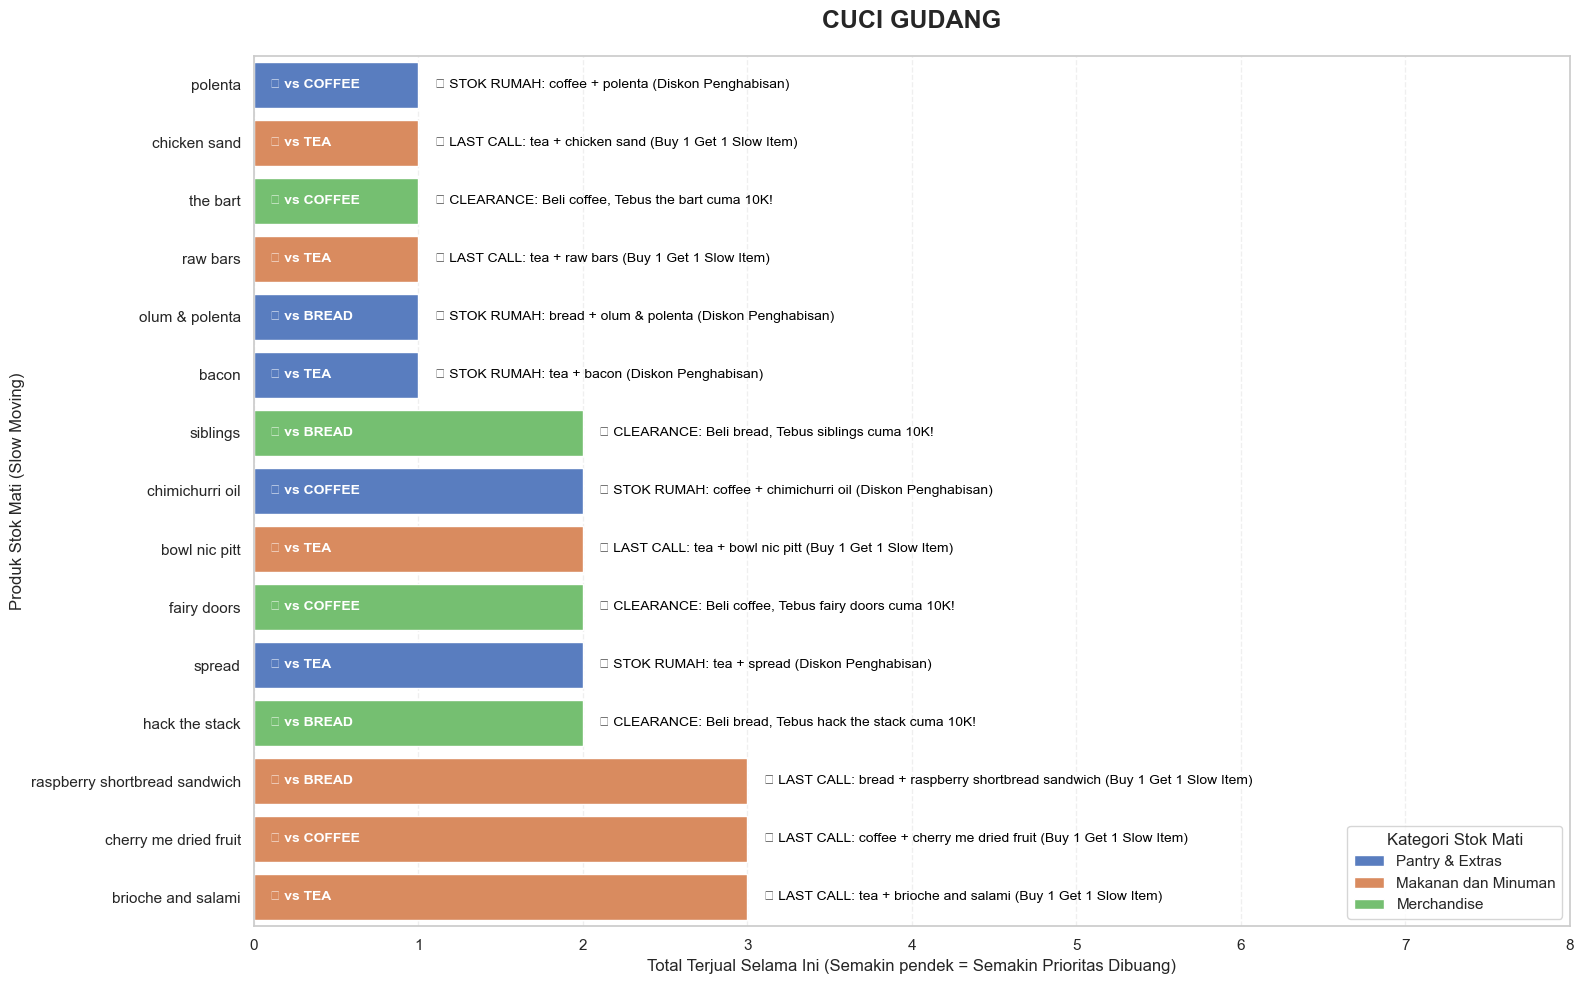

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PERSIAPAN DATA ---
# Ambil 15 item teratas prioritas cuci gudang (yang penjualannya paling rendah)
df_viz = df_cuci_gudang.head(15).copy()

# --- 2. SETUP GRAFIK ---
fig, ax = plt.subplots(figsize=(16, 10))

# Membuat Horizontal Bar Chart
# Kita gunakan 'Terjual_Selama_Ini' sebagai panjang bar (meski pendek, ini menunjukkan betapa "macetnya" stok)
bars = sns.barplot(
    data=df_viz,
    y='Produk_Cuci_Gudang',
    x='Terjual_Selama_Ini',
    hue='Kategori', # Warna berbeda tiap kategori (Pantry, Merch, F&B)
    palette='muted',
    dodge=False,
    ax=ax
)

# --- 3. MENAMBAHKAN INFORMASI STRATEGIS ---

for i, (idx, row) in enumerate(df_viz.iterrows()):
    sales_val = row['Terjual_Selama_Ini']
    hero = row['Dipasangkan_Dengan']
    pesan = row['Strategi_Cuci_Gudang']
    
    # A. Label di DALAM Bar (Menunjukkan Pasangan Hero)
    # Memberi tahu staf: "Item ini harus ditempel ke produk apa?"
    ax.text(
        x = 0.1, # Posisi di awal bar
        y = i, 
        s = f"🔗 vs {hero.upper()}", 
        color='white', 
        va='center', 
        fontweight='bold', 
        fontsize=10
    )
    
    # B. Label di LUAR Bar (Pesan Marketing)
    # Memberi tahu staf: "Apa tulisan promo di papan tulis?"
    ax.text(
        x = sales_val + 0.1, 
        y = i, 
        s = f"📢 {pesan}", 
        color='black', 
        va='center', 
        fontsize=10
    )

# --- 4. FINISHING ---
plt.title('CUCI GUDANG', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Terjual Selama Ini (Semakin pendek = Semakin Prioritas Dibuang)', fontsize=12)
plt.ylabel('Produk Stok Mati (Slow Moving)', fontsize=12)

# Mengatur batas X agar teks promo muat
plt.xlim(0, df_viz['Terjual_Selama_Ini'].max() + 5)

plt.legend(title='Kategori Stok Mati', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()